In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    'GRD.csv',
    encoding='latin-1',
    engine='python',         
    sep=';'           
)
df.columns.tolist()

['COD_HOSPITAL',
 'ID_BENEFICIARIO',
 'SEXO',
 'FECHA_NACIMIENTO',
 'ETNIA',
 'PROVINCIA',
 'COMUNA',
 'NACIONALIDAD',
 'PREVISION',
 'SERVICIO_SALUD',
 'TIPO_PROCEDENCIA',
 'TIPO_INGRESO',
 'ESPECIALIDAD_MEDICA',
 'TIPO_ACTIVIDAD',
 'FECHA_INGRESO',
 'SERVICIOINGRESO',
 'FECHATRASLADO1',
 'SERVICIOTRASLADO1',
 'FECHATRASLADO2',
 'SERVICIOTRASLADO2',
 'FECHATRASLADO3',
 'SERVICIOTRASLADO3',
 'FECHATRASLADO4',
 'SERVICIOTRASLADO4',
 'FECHATRASLADO5',
 'SERVICIOTRASLADO5',
 'FECHATRASLADO6',
 'SERVICIOTRASLADO6',
 'FECHATRASLADO7',
 'SERVICIOTRASLADO7',
 'FECHATRASLADO8',
 'SERVICIOTRASLADO8',
 'FECHATRASLADO9',
 'SERVICIOTRASLADO9',
 'FECHAALTA',
 'SERVICIOALTA',
 'TIPOALTA',
 'CONDICIONDEALTANEONATO1',
 'PESORN1',
 'SEXORN1',
 'RN1ESTADO',
 'CONDICIONDEALTANEONATO2',
 'PESORN2',
 'SEXORN2',
 'RN2ESTADO',
 'CONDICIONDEALTANEONATO3',
 'PESORN3',
 'SEXORN3',
 'RN3ESTADO',
 'CONDICIONDEALTANEONATO4',
 'PESORN4',
 'SEXORN4',
 'RN4ESTADO',
 'DIAGNOSTICO1',
 'DIAGNOSTICO2',
 'DIAGNOSTICO3',
 

In [2]:
cols = [
    'COD_HOSPITAL',
    'ID_BENEFICIARIO',
    'SEXO',
    'FECHA_NACIMIENTO',
    'PROVINCIA',
    'TIPO_PROCEDENCIA',
    'TIPO_INGRESO',
    'ESPECIALIDAD_MEDICA',
    'TIPO_ACTIVIDAD',
    'FECHA_INGRESO',
    'SERVICIOINGRESO',
    'FECHAALTA',
    'TIPOALTA',
    'ESPECIALIDADINTERVENCION',
    'IR_29301_COD_GRD',
    'IR_29301_PESO',
    'IR_29301_SEVERIDAD',
    'IR_29301_MORTALIDAD'
]
#DF CON LAS COLUMNAS QUE USAREMOS
df_filtrado = df[cols]

REGIONES_Y_PROVINCIAS = {
    "Arica y Parinacota": ["ARICA", "PARINACOTA"],
    "Tarapacá": ["IQUIQUE", "TAMARUGAL"],
    "Antofagasta": ["ANTOFAGASTA", "EL LOA", "TOCOPILLA"],
    "Atacama": ["COPIAPO", "CHAÑARAL", "HUASCO"],
    "Coquimbo": ["ELQUI", "LIMARI", "CHOAPA"],
    "Valparaíso": [
        "PETORCA",
        "LOS ANDES",
        "SAN FELIPE",
        "MARGA MARGA",
        "QUILLOTA",
        "VALPARAISO",
        "SAN ANTONIO",
        "ISLA DE PASCUA",
    ],
    "Metropolitana": ["SANTIAGO", "CORDILLERA", "CHACABUCO", "MAIPO", "MELIPILLA", "TALAGANTE"],
    "O'Higgins": ["CACHAPOAL", "CARDENAL CARO", "COLCHAGUA"],
    "Maule": ["TALCA", "CAUQUENES", "CURICO", "LINARES"],
    "Ñuble": ["DIGUILLÍN", "DIGUILLIN", "PUNILLA", "ITATA"],
    "Biobío": ["CONCEPCION", "ARAUCO", "BIO-BIO", "BIO BIO"],
    "La Araucanía": ["MALLECO", "CAUTIN"],
    "Los Ríos": ["VALDIVIA", "RANCO"],
    "Los Lagos": ["LLANQUIHUE", "OSORNO", "CHILOE", "CHILOÉ", "PALENA"],
    "Aysén": ["COIHAIQUE", "AISEN", "GENERAL CARRERA", "CAPITAN PRAT"],
    "Magallanes": [
        "MAGALLANES",
        "ULTIMA ESPERANZA",
        "TIERRA DEL FUEGO",
        "ANTÁRTICA CHILENA",
        "ANTARTICA CHILENA",
    ],
}

PROVINCIA_A_REGION = {
    prov.strip().upper(): region
    for region, lista in REGIONES_Y_PROVINCIAS.items()
    for prov in lista
}

df_filtrado["REGION"] = (
    df_filtrado["PROVINCIA"].astype(str).str.strip().str.upper().map(PROVINCIA_A_REGION)
)
sin_region = df_filtrado["REGION"].isna().sum()
if sin_region:
    print(
        f"Se excluyen {sin_region} filas con provincia desconocida o no mapeable a región. "
    )

df_filtrado = df_filtrado.loc[df_filtrado["REGION"].notna()].copy()
df_filtrado = df_filtrado.loc[df_filtrado["IR_29301_PESO"].notna()].copy()
# QUITAMOS FILAS DONDE NO SE CONOCE EL PESO 
df_filtrado = df_filtrado.loc[
    df_filtrado["IR_29301_PESO"].astype(str).str.strip().str.upper() != "DESCONOCIDO"
].copy()

# 1. Convertir usando format='mixed' y errors='coerce'
# 'mixed' analiza cada fecha por separado por si vienen en distinto formato
# 'coerce' ignora los "DESCONOCIDO" o textos extraños
df_filtrado['FECHA_INGRESO'] = pd.to_datetime(df_filtrado['FECHA_INGRESO'], errors='coerce', dayfirst=True)
df_filtrado['FECHAALTA'] = pd.to_datetime(df_filtrado['FECHAALTA'], errors='coerce', dayfirst=True)
df_filtrado['FECHA_NACIMIENTO'] = pd.to_datetime(df_filtrado['FECHA_NACIMIENTO'], errors='coerce', dayfirst=True)

# 2. Limpieza CRÍTICA: Eliminar filas donde la fecha falló
# Si no borramos los NaT, la resta de fechas dará error más adelante
df_filtrado = df_filtrado.dropna(subset=['FECHA_INGRESO', 'FECHAALTA', 'FECHA_NACIMIENTO'])

df_filtrado['DIAS_ESTADIA'] = (df_filtrado['FECHAALTA'] - df_filtrado['FECHA_INGRESO']).dt.days
df_filtrado['EDAD'] = (df_filtrado['FECHA_INGRESO'].dt.year - df_filtrado['FECHA_NACIMIENTO'].dt.year).astype(int)


/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_9814/1578883768.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado["REGION"] = (


Se excluyen 378 filas con provincia desconocida o no mapeable a región. 


In [3]:
cols_finales = [
    'COD_HOSPITAL',
    'ID_BENEFICIARIO',
    'SEXO',
    'TIPO_PROCEDENCIA',
    'TIPO_INGRESO',
    'ESPECIALIDAD_MEDICA',
    'TIPO_ACTIVIDAD',
    'SERVICIOINGRESO',
    'TIPOALTA',
    'ESPECIALIDADINTERVENCION',
    'IR_29301_COD_GRD',
    'IR_29301_PESO',
    'IR_29301_SEVERIDAD',
    'IR_29301_MORTALIDAD',
    'REGION',
    'DIAS_ESTADIA',
    'EDAD'
]
df_final = df_filtrado[cols_finales]

df_maestras = pd.read_excel(
    'Tablas maestras bases GRD.xlsx', sheet_name='IR - GRD', engine='openpyxl'
)
df_final['IR_29301_COD_GRD'] = df_final['IR_29301_COD_GRD'].astype(str).str.strip()
df_maestras['COD_PROCEDIMIENTO'] = df_maestras['COD_PROCEDIMIENTO'].astype(str).str.strip()

df_final = df_final.merge(
    df_maestras[['COD_PROCEDIMIENTO', 'PROCEDIMIENTO']],
    left_on='IR_29301_COD_GRD',
    right_on='COD_PROCEDIMIENTO',
    how='left',
).drop(columns=['COD_PROCEDIMIENTO'])

# IR_29301_PESO viene con coma decimal (ej. 0,4384); sin convertir, to_numeric da NaN
_peso_num = pd.to_numeric(
    df_final['IR_29301_PESO'].astype(str).str.replace(',', '.', regex=False),
    errors='coerce',
)
df_final['IR_29301_PESO'] = _peso_num
df_final = df_final[
    df_final['SEXO'].astype(str).str.strip().str.upper() != 'DESCONOCIDO'
].copy()
_peso_num = df_final['IR_29301_PESO']
df_final = df_final[(_peso_num > 1.0)]

df_final = (
    df_final.assign(_PESO_NUM=_peso_num)
    .sort_values(by='_PESO_NUM', ascending=False)
    .copy()
)
df_final['COSTO_APROXIMADO'] = df_final['_PESO_NUM'] * 400000
df_final = df_final.drop(columns=['_PESO_NUM'])


/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_9814/88924467.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['IR_29301_COD_GRD'] = df_final['IR_29301_COD_GRD'].astype(str).str.strip()


In [4]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
Index: 306603 entries, 400926 to 1025488
Data columns (total 19 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   COD_HOSPITAL              306603 non-null  int64  
 1   ID_BENEFICIARIO           306603 non-null  object 
 2   SEXO                      306603 non-null  object 
 3   TIPO_PROCEDENCIA          306603 non-null  object 
 4   TIPO_INGRESO              306603 non-null  object 
 5   ESPECIALIDAD_MEDICA       306603 non-null  object 
 6   TIPO_ACTIVIDAD            306603 non-null  object 
 7   SERVICIOINGRESO           306603 non-null  object 
 8   TIPOALTA                  306603 non-null  object 
 9   ESPECIALIDADINTERVENCION  175811 non-null  object 
 10  IR_29301_COD_GRD          306603 non-null  object 
 11  IR_29301_PESO             306603 non-null  float64
 12  IR_29301_SEVERIDAD        306603 non-null  object 
 13  IR_29301_MORTALIDAD       306603 non-null  

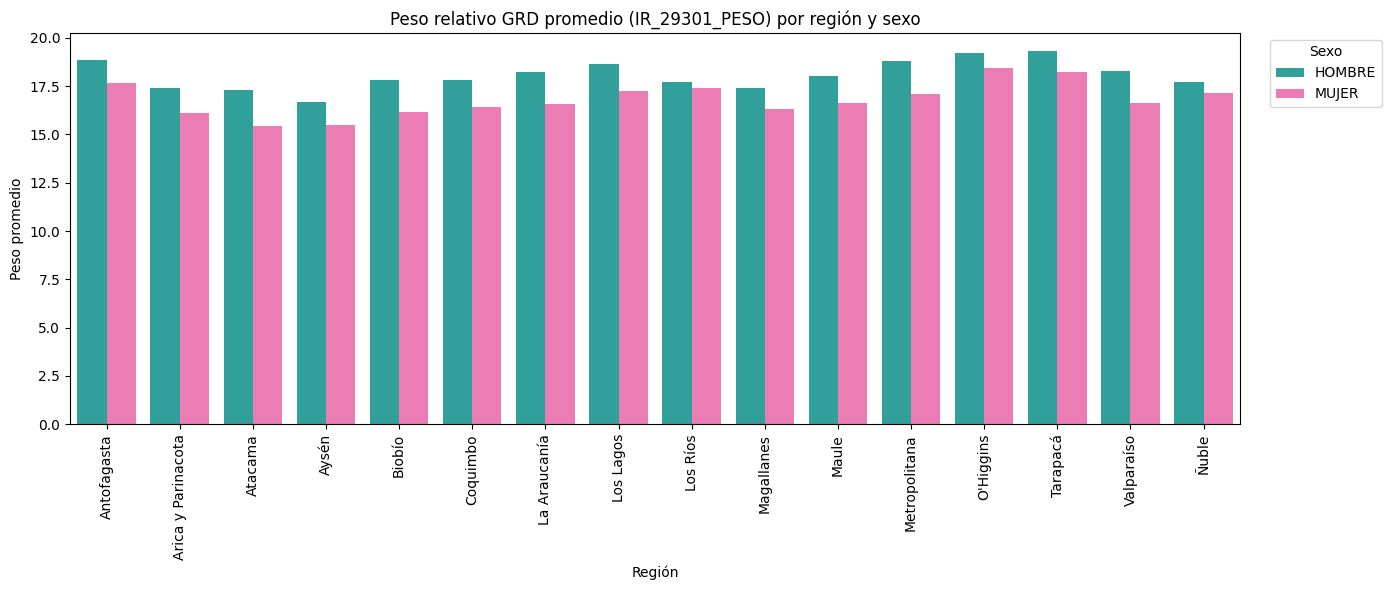

In [5]:
df_peso_region_sexo = df_final.copy()

detalle_peso_region_sexo = (
    df_peso_region_sexo.groupby(['REGION', 'SEXO'], observed=True)
    .agg(
        n_casos=('IR_29301_PESO', 'count'),
        peso_promedio=('IR_29301_PESO', 'mean'),
    )
    .reset_index()
    .sort_values(['REGION', 'SEXO'])
)

tabla_peso_promedio_region_x_sexo = (
    df_peso_region_sexo.pivot_table(
        index='REGION',
        columns='SEXO',
        values='IR_29301_PESO',
        aggfunc='mean',
    )
    .sort_index()
    .round(4)
)
fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=detalle_peso_region_sexo,
    x='REGION',
    y='peso_promedio',
    hue='SEXO',
    palette=['#20B2AA', '#FF69B4'],
    ax=ax,
)
ax.set_title('Peso relativo GRD promedio (IR_29301_PESO) por región y sexo')
ax.set_xlabel('Región')
ax.set_ylabel('Peso promedio')
ax.tick_params(axis='x', rotation=90)
plt.legend(title='Sexo', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

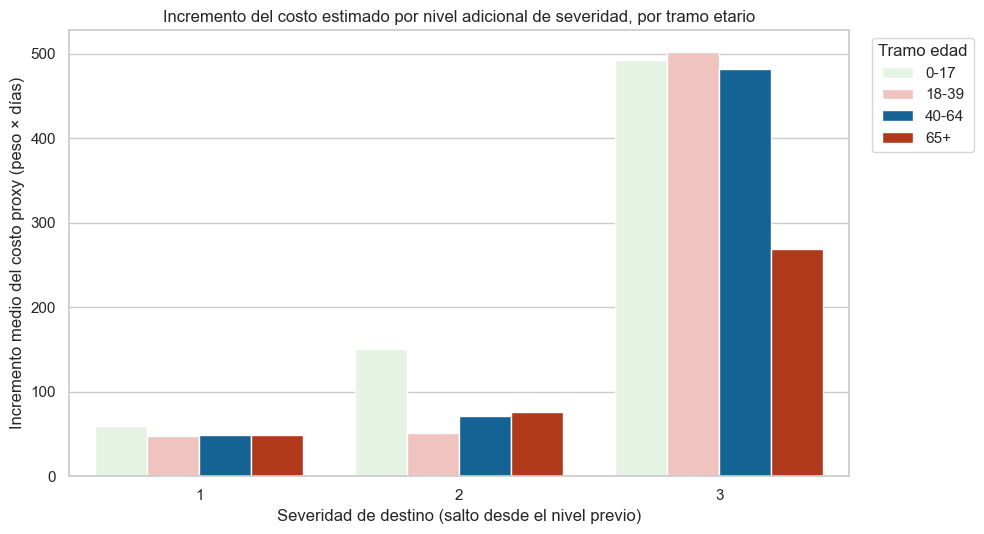

,EDAD_TRAMO,IR_29301_SEVERIDAD,costo_proxy_medio,severidad_nivel_previo,costo_medio_nivel_previo,incremento_costo_por_nivel_severidad
0,0-17,0,13.790606,NaN,NaN,NaN
1,0-17,1,73.523034,0.0,13.790606,59.732428
2,0-17,2,224.099562,1.0,73.523034,150.576528
3,0-17,3,717.221929,2.0,224.099562,493.122368
4,18-39,0,14.558206,NaN,NaN,NaN
5,18-39,1,62.454753,0.0,14.558206,47.896547
6,18-39,2,113.832292,1.0,62.454753,51.377539
7,18-39,3,616.501469,2.0,113.832292,502.669176
8,40-64,0,16.276546,NaN,NaN,NaN
9,40-64,1,65.261110,0.0,16.276546,48.984564


In [6]:
# Incremento del costo estimado (peso × días, COSTO_PROXY) al subir un nivel de severidad GRD,
# dentro del mismo tramo etario (EDAD_TRAMO), con df_final.
df_final['EDAD_TRAMO'] = pd.cut(
    df_final['EDAD'],
    bins=[-1, 17, 39, 64, 200],
    labels=['0-17', '18-39', '40-64', '65+'],
)
_sev = df_final.dropna(subset=['IR_29301_SEVERIDAD', 'EDAD_TRAMO']).copy()
_sev['IR_29301_SEVERIDAD'] = pd.to_numeric(_sev['IR_29301_SEVERIDAD'], errors='coerce')
_sev = _sev.dropna(subset=['IR_29301_SEVERIDAD'])
_sev['COSTO_PROXY'] = _sev['IR_29301_PESO'] * np.maximum(_sev['DIAS_ESTADIA'].clip(lower=0), 1)
incremento_severidad_por_edad = (
    _sev.groupby(['EDAD_TRAMO', 'IR_29301_SEVERIDAD'], observed=True)
    .agg(
        costo_proxy_medio=('COSTO_PROXY', 'mean'),
    )
    .reset_index()
    .sort_values(['EDAD_TRAMO', 'IR_29301_SEVERIDAD'])
)
_g = incremento_severidad_por_edad.groupby('EDAD_TRAMO', observed=True)
incremento_severidad_por_edad['severidad_nivel_previo'] = _g['IR_29301_SEVERIDAD'].shift(1)
incremento_severidad_por_edad['costo_medio_nivel_previo'] = _g['costo_proxy_medio'].shift(1)
incremento_severidad_por_edad['incremento_costo_por_nivel_severidad'] = (
    incremento_severidad_por_edad['costo_proxy_medio']
    - incremento_severidad_por_edad['costo_medio_nivel_previo']
)

_graf = incremento_severidad_por_edad.dropna(subset=['incremento_costo_por_nivel_severidad'])
sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.barplot(
    data=_graf,
    x='IR_29301_SEVERIDAD',
    y='incremento_costo_por_nivel_severidad',
    hue='EDAD_TRAMO',
    palette=['#E1F5E2', '#F7BEB6','#0067AA', '#CA2A02'],
    ax=ax,
)
ax.set_xlabel('Severidad de destino (salto desde el nivel previo)')
ax.set_ylabel('Incremento medio del costo proxy (peso × días)')
ax.set_title('Incremento del costo estimado por nivel adicional de severidad, por tramo etario')
ax.legend(title='Tramo edad', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

incremento_severidad_por_edad

/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_9814/3765636451.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  _r_por_sev = _d.groupby("IR_29301_SEVERIDAD", observed=True).apply(


Correlación Pearson(días, peso) por severidad:
IR_29301_SEVERIDAD
0    0.0052
1    0.0128
2    0.2482
3    0.4284


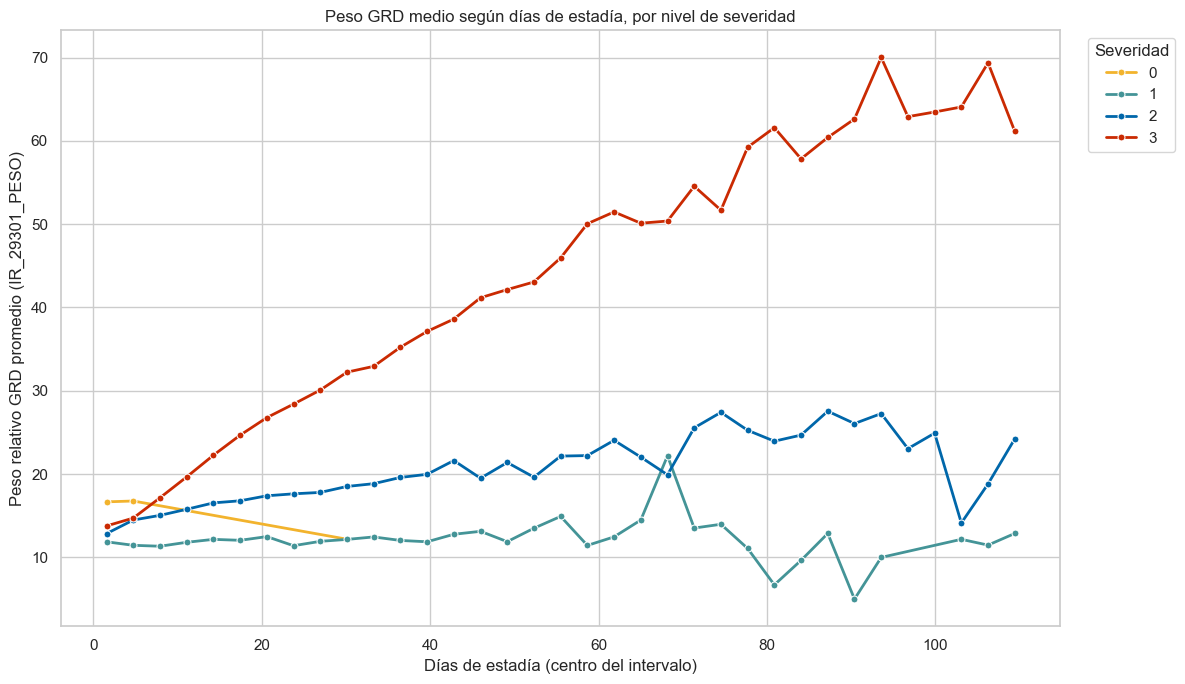

In [7]:
# Pregunta 2: cómo varía la relación estadía–peso GRD según severidad
_cols = ["DIAS_ESTADIA", "IR_29301_PESO", "IR_29301_SEVERIDAD"]
_d = df_final.dropna(subset=_cols).copy()
_d["IR_29301_SEVERIDAD"] = _d["IR_29301_SEVERIDAD"].astype(int)

# Correlación de Pearson por nivel (toda la base válida)
_r_por_sev = _d.groupby("IR_29301_SEVERIDAD", observed=True).apply(
    lambda g: g["DIAS_ESTADIA"].corr(g["IR_29301_PESO"])
)
print("Correlación Pearson(días, peso) por severidad:")
print(_r_por_sev.round(4).to_string())

# Recorte de cola de días; promedios por intervalo de días (eje X) y peso medio (eje Y)
_p99 = _d["DIAS_ESTADIA"].quantile(0.995)
_dc = _d.loc[_d["DIAS_ESTADIA"] <= _p99].copy()
_max_d = float(_dc["DIAS_ESTADIA"].max())
_n_bins = 35
_edges = np.linspace(0, _max_d, _n_bins + 1)
_dc["dias_bin"] = pd.cut(_dc["DIAS_ESTADIA"], bins=_edges, include_lowest=True)
_agg = (
    _dc.groupby(["dias_bin", "IR_29301_SEVERIDAD"], observed=False)
    .agg(peso_promedio=("IR_29301_PESO", "mean"), n=("IR_29301_PESO", "size"))
    .reset_index()
)
_agg["dias_mid"] = _agg["dias_bin"].apply(lambda iv: iv.mid if pd.notna(iv) else np.nan)
_agg["Severidad"] = _agg["IR_29301_SEVERIDAD"].astype(str)
_agg = _agg.dropna(subset=["dias_mid"])

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(12, 7))
sns.lineplot(
    data=_agg,
    x="dias_mid",
    y="peso_promedio",
    hue="Severidad",
    marker="o",
    markersize=5,
    linewidth=2,
    ax=ax,
    palette=['#F2B32D', '#449497','#0067AA', '#CA2A02'],
    errorbar=None,
)
ax.set_xlabel("Días de estadía (centro del intervalo)")
ax.set_ylabel("Peso relativo GRD promedio (IR_29301_PESO)")
ax.set_title("Peso GRD medio según días de estadía, por nivel de severidad")
plt.legend(title="Severidad", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_9814/2287930092.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_plot, x="score_perfil", y="etiqueta", ax=ax2, palette="YlGnBu")


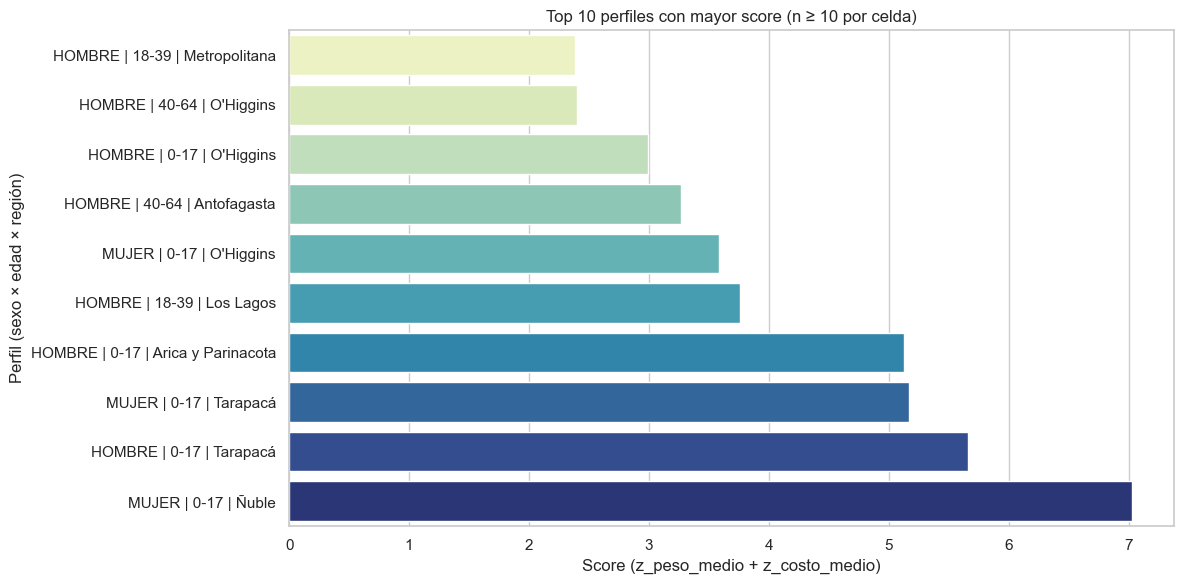

In [8]:
# Definir MIN_CASOS_GRUPO si no está definido
MIN_CASOS_GRUPO = 10

# Crear perfil_socio_top: sexo × tramo edad × región con score
if "EDAD_TRAMO" not in df_final.columns:
    df_final["EDAD_TRAMO"] = pd.cut(
        df_final["EDAD"],
        bins=[-1, 17, 39, 64, 200],
        labels=["0-17", "18-39", "40-64", "65+"],
    )

_df_socio = df_final.copy()
agrupado_socio = (
    _df_socio.groupby(["SEXO", "EDAD_TRAMO", "REGION"], observed=True)
    .agg(
        n=("IR_29301_PESO", "count"),
        peso_medio=("IR_29301_PESO", "mean"),
        costo_medio=("COSTO_APROXIMADO", "mean"),
    )
    .reset_index()
)
agrupado_socio = agrupado_socio.loc[agrupado_socio["n"] >= MIN_CASOS_GRUPO].copy()

# Calcular score como suma de z-scores
agrupado_socio["z_peso"] = (agrupado_socio["peso_medio"] - agrupado_socio["peso_medio"].mean()) / agrupado_socio["peso_medio"].std()
agrupado_socio["z_costo"] = (agrupado_socio["costo_medio"] - agrupado_socio["costo_medio"].mean()) / agrupado_socio["costo_medio"].std()
agrupado_socio["score_perfil"] = agrupado_socio["z_peso"] + agrupado_socio["z_costo"]

perfil_socio_top = agrupado_socio.sort_values("score_perfil", ascending=False)

# Ahora sí, el código del Top 10
top10_plot = perfil_socio_top.head(10).copy()
top10_plot["etiqueta"] = (
    top10_plot["SEXO"].astype(str).str.strip()
    + " | "
    + top10_plot["EDAD_TRAMO"].astype(str)
    + " | "
    + top10_plot["REGION"].astype(str)
)
top10_plot = top10_plot.sort_values("score_perfil", ascending=True)
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(data=top10_plot, x="score_perfil", y="etiqueta", ax=ax2, palette="YlGnBu")
ax2.set_xlabel("Score (z_peso_medio + z_costo_medio)")
ax2.set_ylabel("Perfil (sexo × edad × región)")
ax2.set_title(
    f"Top 10 perfiles con mayor score (n ≥ {MIN_CASOS_GRUPO} por celda)"
)
plt.tight_layout()
plt.show()

/var/folders/8n/xv5_cp7j60n4skf9m8qrrk9h0000gn/T/ipykernel_9814/1267237363.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Top 10 perfiles (sexo × tramo edad × procedimiento) por costo estimado medio (COSTO_APROXIMADO = IR_29301_PESO × 400.000), n ≥ 10:
  SEXO EDAD_TRAMO                                                        PROCEDIMIENTO   n  costo_estimado_medio
HOMBRE       0-17     PH NEONATO, PESO AL NACER <1000 GR CON PROCEDIMIENTO MAYOR W/MCC  26            82584400.0
 MUJER       0-17     PH NEONATO, PESO AL NACER <1000 GR CON PROCEDIMIENTO MAYOR W/MCC  35            82584400.0
HOMBRE      40-64                            PH TRASPLANTE CARDIACO Y/O PULMONAR W/MCC  12            68565600.0
HOMBRE       0-17 PH NEONATO, PESO AL NACER 1000-1499 GR CON PROCEDIMIENTO MAYOR W/MCC  20            62695600.0
 MUJER       0-17 PH NEONATO, PESO AL NACER 1000-1499 GR CON PROCEDIMIENTO MAYOR W/MCC  17            62695600.0
 MUJER       0-17                         PH TRASPLANTE ALOGÉNICO DE MÉDULA ÓSEA W/MCC  14            56996800.0
 MUJER      18-39                         PH TRASPLANTE ALOGÉNICO DE MÉDULA ÓS

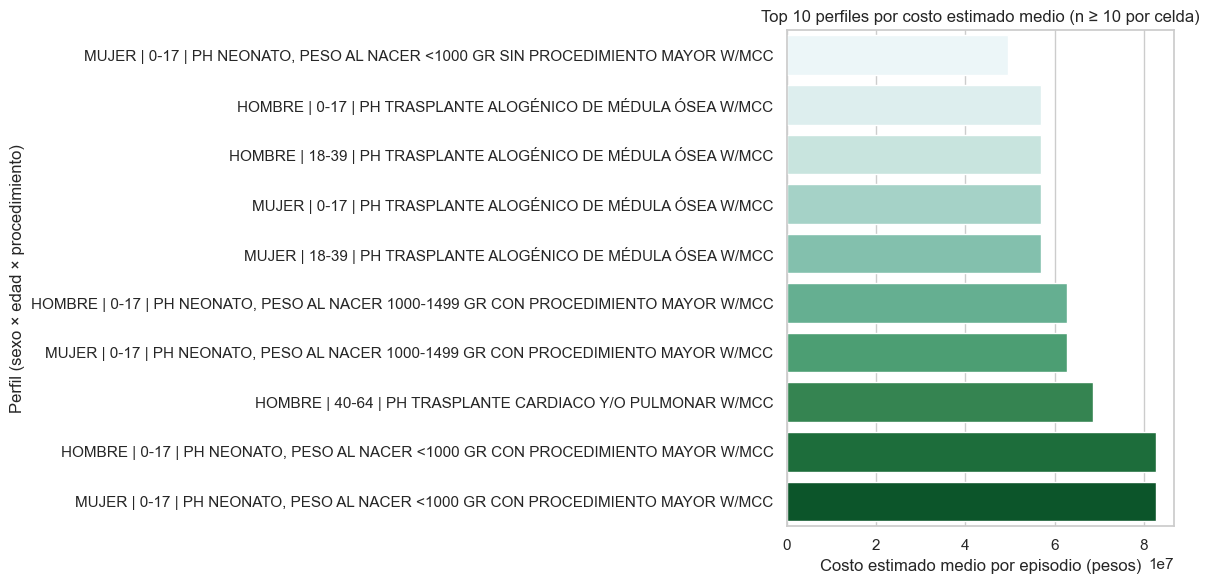


Ranking solo por sexo × tramo edad (n ≥ 10):
  SEXO EDAD_TRAMO     n  costo_estimado_medio
 MUJER       0-17 19407          7.639848e+06
HOMBRE      40-64 49963          7.633572e+06
HOMBRE      18-39 19838          7.487050e+06
HOMBRE       0-17 23305          7.383303e+06
HOMBRE        65+ 65960          7.066352e+06
 MUJER      40-64 44853          6.833219e+06
 MUJER        65+ 64155          6.511613e+06
 MUJER      18-39 19122          6.420760e+06


In [9]:
# Top perfiles por costo estimado medio (SEXO × tramo edad × procedimiento GRD), mismo criterio de celda que el score
MIN_CASOS_GRUPO = 10
TOP_N_COSTO = 10

if "EDAD_TRAMO" not in df_final.columns:
    df_final["EDAD_TRAMO"] = pd.cut(
        df_final["EDAD"],
        bins=[-1, 17, 39, 64, 200],
        labels=["0-17", "18-39", "40-64", "65+"],
    )

_df_costo = df_final.dropna(subset=["PROCEDIMIENTO"])
agrupado_costo = (
    _df_costo.groupby(["SEXO", "EDAD_TRAMO", "PROCEDIMIENTO"], observed=True)
    .agg(
        n=("COSTO_APROXIMADO", "count"),
        costo_estimado_medio=("COSTO_APROXIMADO", "mean"),
    )
    .reset_index()
)
agrupado_costo = agrupado_costo.loc[agrupado_costo["n"] >= MIN_CASOS_GRUPO].copy()
perfil_costo_top = agrupado_costo.sort_values("costo_estimado_medio", ascending=False)
perfil_costo_top20 = perfil_costo_top.head(TOP_N_COSTO)

print(
    f"Top {TOP_N_COSTO} perfiles (sexo × tramo edad × procedimiento) por costo estimado medio "
    f"(COSTO_APROXIMADO = IR_29301_PESO × 400.000), n ≥ {MIN_CASOS_GRUPO}:"
)
print(perfil_costo_top20.to_string(index=False))

top20_costo_plot = perfil_costo_top20.copy()
_proc_txt = top20_costo_plot["PROCEDIMIENTO"].astype(str).str.strip()
_proc_corto = np.where(
    _proc_txt.str.len() > 90,
    _proc_txt.str.slice(0, 87) + "...",
    _proc_txt,
)
top20_costo_plot["etiqueta"] = (
    top20_costo_plot["SEXO"].astype(str).str.strip()
    + " | "
    + top20_costo_plot["EDAD_TRAMO"].astype(str)
    + " | "
    + _proc_corto
)
top20_costo_plot = top20_costo_plot.sort_values("costo_estimado_medio", ascending=True)
sns.set_theme(style="whitegrid")
fig_costo, ax_costo = plt.subplots(figsize=(12, max(6, TOP_N_COSTO * 0.45)))
sns.barplot(
    data=top20_costo_plot,
    x="costo_estimado_medio",
    y="etiqueta",
    ax=ax_costo,
    palette="BuGn",
)
ax_costo.set_xlabel("Costo estimado medio por episodio (pesos)")
ax_costo.set_ylabel("Perfil (sexo × edad × procedimiento)")
ax_costo.set_title(
    f"Top {TOP_N_COSTO} perfiles por costo estimado medio (n ≥ {MIN_CASOS_GRUPO} por celda)"
)
plt.tight_layout()
plt.show()

# Solo sexo × tramo etario (como máximo 8 celdas): mismo costo, para tabla compacta
_rank_sexo_edad = (
    df_final.groupby(["SEXO", "EDAD_TRAMO"], observed=True)
    .agg(
        n=("COSTO_APROXIMADO", "count"),
        costo_estimado_medio=("COSTO_APROXIMADO", "mean"),
    )
    .reset_index()
)
_rank_sexo_edad = _rank_sexo_edad.loc[_rank_sexo_edad["n"] >= MIN_CASOS_GRUPO].sort_values(
    "costo_estimado_medio", ascending=False
)
print(f"\nRanking solo por sexo × tramo edad (n ≥ {MIN_CASOS_GRUPO}):")
print(_rank_sexo_edad.to_string(index=False))

## Estimación estadística

In [10]:
# ==============================================================================
# ESTIMACIÓN ESTADÍSTICA
# ==============================================================================

# 1. PARÁMETROS DE INTERÉS: PROMEDIOS
print("=" * 80)
print("1. ESTIMADORES PUNTUALES - PROMEDIOS")
print("=" * 80)

# Promedio general de peso
promedio_peso_general = df_final['IR_29301_PESO'].mean()
std_peso_general = df_final['IR_29301_PESO'].std()
n_casos = len(df_final)
se_peso = std_peso_general / np.sqrt(n_casos)

print(f"\nPeso relativo GRD (IR_29301_PESO):")
print(f"  Promedio: {promedio_peso_general:.4f}")
print(f"  Desv. Est.: {std_peso_general:.4f}")
print(f"  Error estándar: {se_peso:.4f}")
print(f"  N casos: {n_casos}")

# Promedios por sexo
print(f"\nPromedio de peso por SEXO:")
promedio_peso_sexo = df_final.groupby('SEXO', observed=True)['IR_29301_PESO'].agg(['mean', 'std', 'count'])
promedio_peso_sexo.columns = ['Promedio', 'Desv. Est.', 'N']
promedio_peso_sexo['Error Estándar'] = promedio_peso_sexo['Desv. Est.'] / np.sqrt(promedio_peso_sexo['N'])
print(promedio_peso_sexo.round(4))

# Promedios por región
print(f"\nPromedio de peso por REGIÓN:")
promedio_peso_region = df_final.groupby('REGION', observed=True)['IR_29301_PESO'].agg(['mean', 'std', 'count'])
promedio_peso_region.columns = ['Promedio', 'Desv. Est.', 'N']
promedio_peso_region['Error Estándar'] = promedio_peso_region['Desv. Est.'] / np.sqrt(promedio_peso_region['N'])
print(promedio_peso_region.round(4))

# Promedios por tramo etario
print(f"\nPromedio de peso por TRAMO ETARIO:")
promedio_peso_edad = df_final.groupby('EDAD_TRAMO', observed=True)['IR_29301_PESO'].agg(['mean', 'std', 'count'])
promedio_peso_edad.columns = ['Promedio', 'Desv. Est.', 'N']
promedio_peso_edad['Error Estándar'] = promedio_peso_edad['Desv. Est.'] / np.sqrt(promedio_peso_edad['N'])
print(promedio_peso_edad.round(4))

# ==============================================================================
# 2. PROPORCIONES
# ==============================================================================
print("\n" + "=" * 80)
print("2. PROPORCIONES")
print("=" * 80)

# Proporción por sexo
print(f"\nProporción de casos por SEXO:")
prop_sexo = df_final['SEXO'].value_counts(normalize=True).sort_index()
count_sexo = df_final['SEXO'].value_counts().sort_index()
prop_table_sexo = pd.DataFrame({
    'Frecuencia': count_sexo,
    'Proporción': prop_sexo,
    'Porcentaje': prop_sexo * 100
})
print(prop_table_sexo.round(4))

# Proporción por severidad
print(f"\nProporción de casos por SEVERIDAD:")
df_final['IR_29301_SEVERIDAD'] = pd.to_numeric(df_final['IR_29301_SEVERIDAD'], errors='coerce')
_sev_clean = df_final.dropna(subset=['IR_29301_SEVERIDAD'])
prop_sev = _sev_clean['IR_29301_SEVERIDAD'].value_counts(normalize=True).sort_index()
count_sev = _sev_clean['IR_29301_SEVERIDAD'].value_counts().sort_index()
prop_table_sev = pd.DataFrame({
    'Frecuencia': count_sev,
    'Proporción': prop_sev,
    'Porcentaje': prop_sev * 100
})
print(prop_table_sev.round(4))

# Proporción por tipo de alta
print(f"\nProporción de casos por TIPO DE ALTA:")
prop_alta = df_final['TIPOALTA'].value_counts(normalize=True)
count_alta = df_final['TIPOALTA'].value_counts()
prop_table_alta = pd.DataFrame({
    'Frecuencia': count_alta,
    'Proporción': prop_alta,
    'Porcentaje': prop_alta * 100
})
print(prop_table_alta.round(4))

# ==============================================================================
# 3. COMPARACIÓN ENTRE GRUPOS (Tests de medias)
# ==============================================================================
print("\n" + "=" * 80)
print("3. COMPARACIÓN ENTRE GRUPOS")
print("=" * 80)

from scipy import stats

# T-test: Peso por sexo
print(f"\nT-test: Diferencia de peso según SEXO")
grupos_sexo = df_final.groupby('SEXO', observed=True)['IR_29301_PESO'].apply(list)
if len(grupos_sexo) == 2:
    grupo1, grupo2 = grupos_sexo.iloc[0], grupos_sexo.iloc[1]
    t_stat, p_value = stats.ttest_ind(grupo1, grupo2)
    print(f"  T-statistic: {t_stat:.4f}")
    print(f"  P-value: {p_value:.6f}")
    print(f"  Significancia: {'Sí' if p_value < 0.05 else 'No'} (α=0.05)")

# ANOVA: Peso por tramo etario
print(f"\nANOVA: Diferencia de peso según TRAMO ETARIO")
grupos_edad = [group['IR_29301_PESO'].values for name, group in df_final.groupby('EDAD_TRAMO', observed=True)]
f_stat, p_value_anova = stats.f_oneway(*grupos_edad)
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value_anova:.6f}")
print(f"  Significancia: {'Sí' if p_value_anova < 0.05 else 'No'} (α=0.05)")

# ANOVA: Peso por severidad
print(f"\nANOVA: Diferencia de peso según SEVERIDAD")
_df_sev_stats = df_final.dropna(subset=['IR_29301_SEVERIDAD']).copy()
_df_sev_stats['IR_29301_SEVERIDAD'] = pd.to_numeric(_df_sev_stats['IR_29301_SEVERIDAD'], errors='coerce')
_df_sev_stats = _df_sev_stats.dropna(subset=['IR_29301_SEVERIDAD'])
grupos_sev = [group['IR_29301_PESO'].values for name, group in _df_sev_stats.groupby('IR_29301_SEVERIDAD')]
if len(grupos_sev) > 1:
    f_stat_sev, p_value_sev = stats.f_oneway(*grupos_sev)
    print(f"  F-statistic: {f_stat_sev:.4f}")
    print(f"  P-value: {p_value_sev:.6f}")
    print(f"  Significancia: {'Sí' if p_value_sev < 0.05 else 'No'} (α=0.05)")

# Comparación de costo medio por región
print(f"\nCostos promedio estimados por REGIÓN:")
costo_region = df_final.groupby('REGION', observed=True)['COSTO_APROXIMADO'].agg(['mean', 'std', 'count'])
costo_region.columns = ['Costo Medio', 'Desv. Est.', 'N']
costo_region = costo_region.sort_values('Costo Medio', ascending=False)
print(costo_region.round(0))

print("\n" + "=" * 80)

1. ESTIMADORES PUNTUALES - PROMEDIOS

Peso relativo GRD (IR_29301_PESO):
  Promedio: 17.6399
  Desv. Est.: 16.8321
  Error estándar: 0.0304
  N casos: 306603

Promedio de peso por SEXO:
        Promedio  Desv. Est.       N  Error Estándar
SEXO                                                
HOMBRE   18.3586     17.6434  159066          0.0442
MUJER    16.8650     15.8747  147537          0.0413

Promedio de peso por REGIÓN:
                    Promedio  Desv. Est.       N  Error Estándar
REGION                                                          
Antofagasta          18.3127     18.5315    8291          0.2035
Arica y Parinacota   16.8496     14.8854    4718          0.2167
Atacama              16.3901     14.9234    5573          0.1999
Aysén                16.0943     13.3198    3133          0.2380
Biobío               17.0100     15.9577   33816          0.0868
Coquimbo             17.1365     15.7133   13759          0.1340
La Araucanía         17.4373     16.6482   19814    